In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io
import seaborn as sns
import networkx as nx


import pingouin as pg


----------------------------- CONSIDERACIONES GENERALES --------------------------------------

1.-For shortest path and global efficiency, authors use bct.distance_bin converting the connectome to a non-weighted matrix. Also run with gamma=1 as default. We propose to use bct.distance_wei with alpha=0.6 (not implemented yet)

2.-Authors perform fit to GAM with dataset and sex as numerical values, which is incorrect. We propose to use as.factor() in the R script (not implemented).

3.-Pearson correlations are not calculated on raw data, but on GAMs residuals, eliminating the influence of covariates and dataset/atlas.   

4.-Authors calculate age grouped variable for correlations, although they don't use them finally. We propose to not use age grouped variables, which would artificially inflate correlations.

5.-"Neurotypical subjects are included in harmonization but they are not in the final harmonized dataset. I would have to run ComBAT myself to get them. They are part of the CALM dataset." Now that we are using thresholded instead of harmonized data, we choose to keep them.  

6.-Using variable density turning points (Suppl. Fig 10.d) is valid since the authors used Uniform Manifold Approximation and Projection on 11 variables and fitted to a reasonable degree polynomial. Adding one more variable and rerunning UMAP again would probably not change much, but disregarding epochs or calculating disparity-only epochs underestimates the statistical power of all other graph metrics across the lifespan. 

7.-If we chose to "not trust" the results of the authors but also not process connectomes in QSIprep, we can use datasets processed in brain.labsolver.org, see Suppl. Tab. 1, processed by Dr. Yeh himself ._. 

8.- Using thresholding data means that only R will try to eliminate the influence of dataset and atlas as covariates. 


In [23]:
#Import demographics data and connectome matrices. Density outliers (14) have been excluded but non neurotypical (315) have been included.

data=pd.read_csv('procdata/demographics_with_graph_metrics.csv')
print(data.head())

from pymatreader import read_mat
connectomes_vd = read_mat('preprocdata/thresholded_data.mat')['thresholded_data']['connectomes']['variable_normalized_weighted'] #variable density for our analysis.
connectomes_cd = read_mat('preprocdata/thresholded_data.mat')['thresholded_data']['connectomes']['controlled_normalized_weighted'] #constant density.

print(f"Matrices found: {connectomes_vd.shape}")
print(f"Subjects: {connectomes_vd.shape[0]}, Regions: {connectomes_vd.shape[1]}")


   Subject  age  sex  dataset  atlas  group  remove_index  Strength  \
0        0    0    0        1      1      1             0  0.999506   
1        1    0    0        1      1      1             0  1.106468   
2        2    0    0        1      1      1             0  1.301185   
3        3    0    1        1      1      1             0  1.239519   
4        4    0    0        1      1      1             0  0.911820   

   Strength_CD  Disparity_Y  Disparity_CD  Clustering_Coefficient  \
0     0.951708     0.225003      0.250867                0.036474   
1     1.035239     0.214476      0.266598                0.035123   
2     1.191552     0.178239      0.232418                0.040813   
3     1.179212     0.232977      0.251770                0.040115   
4     0.845776     0.205915      0.262017                0.029702   

   Average_Shortest_Path  Global_Efficiency      Diameter  Modularity  \
0               2.527934           0.458487  1.000000e+20    0.432573   
1           

c:\Users\Ale\miniconda3\envs\snakes\Lib\site-packages\pymatreader\utils.py:304: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(


Matrices found: (4202, 90, 90)
Subjects: 4202, Regions: 90


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
sns.set_theme(style="ticks", context="paper")

# Usamos common_norm=False para que cada dataset sume 1 independientemente,
# así puedes comparar la distribución de edades sin que el N de cada uno distorsione.
sns.kdeplot(
    data=demo, x='age', hue='dataset', 
    common_norm=False, fill=True, alpha=0.3, linewidth=1.5, ax=ax, palette='tab10'
)

ax.set_xlabel('Age')
ax.set_ylabel('Density (Overlap Proxy)')
sns.despine()

plt.tight_layout()
plt.show()

Because density changes non linearly across lifespan, computing GAM residuals using density as a covariate would flatten disparity effect (not tested) and trying to extract residuals using a non linear spline variable density in GAM introduces the problem of concurvity (multicolinearity, but non linear), but does consider non linearity in density. So we can compare both 2 approaches (variable density, variable density using GAM residuals with density introducing it as spline covariate). See results below after running Isolate_disparity_age_relationship.R

It is standard practice to used density controlled connectomes, but in this case we do care about the small edges, appart from density variable connectomes being already thresholded to 0.7 strength in each age group (suppress scanner noise: counting inexisting fibers), see Suppl Fig 1.

In [25]:
df_disp = pd.read_csv('procdata/disparity_residuals.csv')

print("Disparity residuals correlation with age:\n")
res_full = pg.corr(df_disp['age'], df_disp['disparity_res'], method='pearson')
print(res_full)
print("\nDisparity residuals correlation with age (Density Spline Covariate Residuals):\n")
res_full_splinedensity = pg.corr(df_disp['age'], df_disp['disparity_res_sden'], method='pearson')
print(res_full_splinedensity)


Disparity residuals correlation with age:

            n         r          CI95         p_val       BF10  power
pearson  4202  0.250752  [0.22, 0.28]  2.903974e-61  3.053e+57    1.0

Disparity residuals correlation with age (Density Spline Covariate Residuals):

            n         r          CI95         p_val       BF10  power
pearson  4202  0.253125  [0.22, 0.28]  1.969838e-62  4.453e+58    1.0


We choose to take disparity-age residuals with thresholded data as the definitive age-disparity relation and density spline covariate residuals to be taken as a verification method. 

----------------------------- VERIFICACIÓN RESPECTO AL MODELO NULO DE PESOS ALEATORIAMENTE DISTRIBUIDOS-----------------------------

1.-Comparisson of all nodes to the randomly distributed weights null model

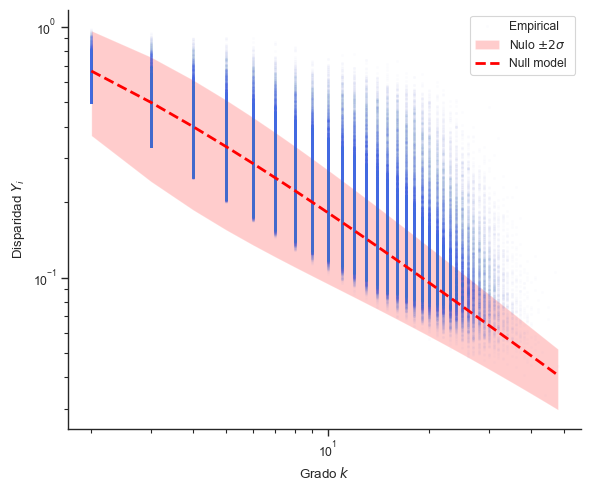

In [26]:

def calc_node_disparity(adj):
    """Calcula grado k_i y disparidad Y_i."""
    k = np.count_nonzero(adj, axis=1)
    s = np.sum(adj, axis=1)
    s_safe = np.where(s == 0, 1, s)
    
    p = adj / s_safe[:, None]
    Y = np.sum(p**2, axis=1)
    return k, Y

def null_model_stats(k):
    """Calcula la media y desviación estándar analítica del modelo nulo de Serrano."""
    Y_mean = 2.0 / (k + 1.0)
    # Varianza teórica exacta
    Y_var = (4.0 * (k - 1.0)) / ((k + 1.0)**2 * (k + 2.0) * (k + 3.0))
    Y_std = np.sqrt(np.maximum(Y_var, 0)) # Asegurar no negativos por redondeo
    return Y_mean, Y_std

# 1. Extraer k y Y de TODOS los conectomas
k_all = []
Y_all = []

# Asumiendo que connectomes_vd es tu array de (3802, 90, 90)
for adj in connectomes_vd:
    k, Y = calc_node_disparity(adj)
    mask = k > 1
    k_all.append(k[mask])
    Y_all.append(Y[mask])

# Aplanar listas en arrays 1D
k_all = np.concatenate(k_all)
Y_all = np.concatenate(Y_all)

# 2. Generar el plot (Heatmap + Null Model)
plt.figure(figsize=(6, 5))
sns.set_theme(style="ticks", context="paper")

# Scatter plot en lugar de hexbin (ideal para nubes de puntos densas)
plt.plot(k_all, Y_all, 'o', color='royalblue', alpha=0.02, markersize=2, markeredgecolor='none', label='Empirical')
plt.xscale('log')
plt.yscale('log')
# Calcular modelo nulo continuo para las líneas
k_range = np.arange(2, k_all.max() + 1)
Y_null_mean, Y_null_std = null_model_stats(k_range)

# Sombreado 2-sigma
plt.fill_between(k_range, 
                 Y_null_mean - 2*Y_null_std, 
                 Y_null_mean + 2*Y_null_std, 
                 color='red', alpha=0.2, edgecolor=None, label=r'Nulo $\pm 2\sigma$')

# Línea del modelo nulo
plt.plot(k_range, Y_null_mean, color='red', linestyle='--', linewidth=2, label='Null model ')

# Añadir la línea de promedios empíricos
#df_mean = pd.DataFrame({'k': k_all, 'Y': Y_all}).groupby('k').mean()
#plt.plot(df_mean.index, df_mean['Y'], color='black', marker='o', markersize=4, 
         #linewidth=1.5, label=r'Empírico $\langle Y \rangle$')

plt.xlabel(r'Grado $k$')
plt.ylabel(r'Disparidad $Y_i$')
sns.despine()
plt.legend()
plt.tight_layout()

plt.savefig('results/disparity/disparity_heatmap_null_model.png', dpi=300)
plt.show()

2.- Seeing that there are many nodes outside whose disparity differ from the null model, we can group those nodes by subject and calculate a mean deviation. This way we can calculate how does this deviation \Delta Y change with age. 

**Another option** is to not group nodes by subject. Every subject has an age, but so does every node belonging to the subject. We usually understand the brain as a whole and calculating correlations of nodes of subjects instead of whole brain averages may seem too cold but save the study.

In [31]:
def get_global_disparity_deviation(adj):
    k, Y = calc_node_disparity(adj)
    mask = k > 1
    
    if np.sum(mask) == 0:
        return np.nan
        
    Y_null = 2.0 / (k[mask] + 1.0)
    deviation = Y[mask] - Y_null
    
    return np.mean(deviation)

deviations = [get_global_disparity_deviation(adj) for adj in connectomes_vd]

# 3. Añadir al dataframe y guardar
data['Disparity_Deviation'] = deviations

# Eliminar posibles NaNs si algún sujeto falló o tenía k<=1 en todos los nodos
data = data.dropna(subset=['Disparity_Deviation'])

data.to_csv('procdata/demographics_with_disparity_dev.csv', index=False)

3.-We send to R to calculate the residuals, just like with global disparity. The y axis of this plot is harder to interpret though. We plot side by side disparity null model deviation and the residuals (harmonized data). Again, we perform an epoch analysis on the residuals after running disparity_null_residuals&epochs.R. In gam model, gamma was set to 1.4 to account for the bigger dataset. Other values of gamma were tested and we got very similar results

C:\Users\Ale\AppData\Local\Temp\ipykernel_13788\3986522205.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()
C:\Users\Ale\AppData\Local\Temp\ipykernel_13788\3986522205.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


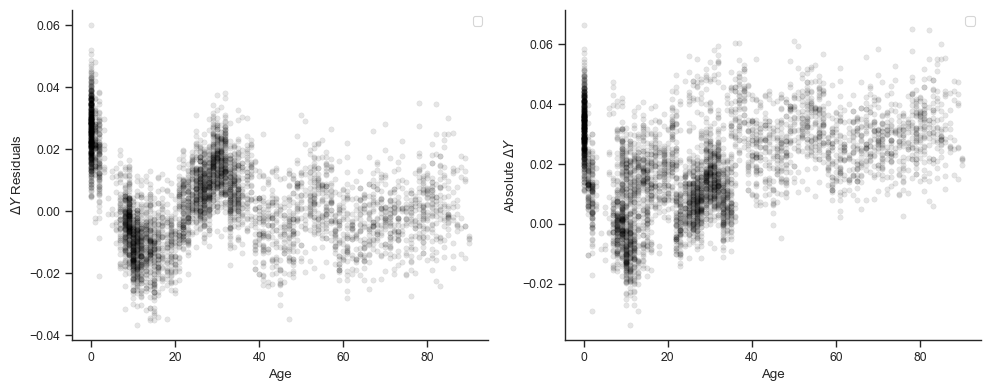

In [44]:
df_dev = pd.read_csv('procdata/disparity_residuals_dev.csv')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.set_theme(style="ticks", context="paper")

# Nube de puntos
sns.scatterplot(
    data=df_dev,
    x='age',
    y='disparity_res_dev',
    alpha=0.1, color='black', s=15, edgecolor=None, ax=ax[0]
)

ax[0].set_xlabel('Age')
ax[0].set_ylabel(r'$\Delta Y$ Residuals')
sns.despine()
ax[0].legend()

sns.scatterplot(
    data=data,
    x='age',
    y='Disparity_Deviation',
    alpha=0.1, color='black', s=15, edgecolor=None, ax=ax[1]
)   
ax[1].set_xlabel('Age')
ax[1].set_ylabel(r'Absolute $\Delta Y$')
sns.despine()
ax[1].legend()

plt.tight_layout()
plt.savefig('results/disparity/disparity_deviation_absolute_epochs.png', dpi=300)
plt.show()


----------------------------------------- TURNING POINTS Y DISPARIDAD POR EPOCHS --------------------------------------

1.- OPTION 1: We fit in R: disparity_gam_epochs.R and identify turning points. We stablis epochs based on the comparisson with the null model. 

Epoch        Range    N      r   p-value
   E1   0.0 - 13.6 1403 -0.884  0.00e+00
   E2  13.6 - 30.0 1065  0.731 1.40e-178
   E3  30.0 - 41.8  674 -0.543  6.64e-53
   E4  41.8 - 50.9  220  0.192  4.20e-03
   E5  50.9 - 65.5  361 -0.423  3.89e-17
   E6  65.5 - 83.6  406  0.164  9.11e-04
   E7 83.6 - 100.0   73 -0.163  1.67e-01


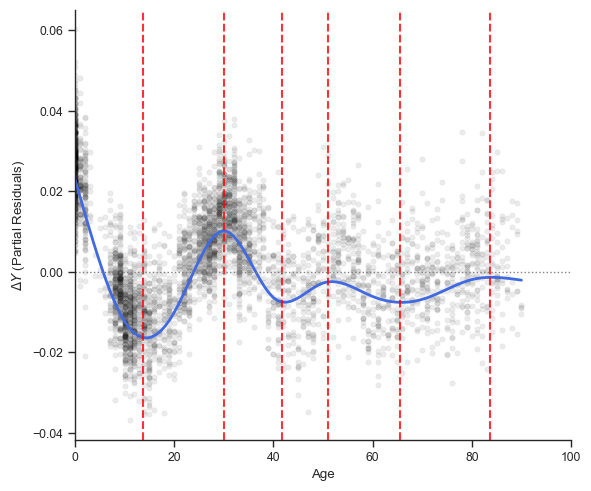

In [49]:


# 1. Load R Exports
df_dev = pd.read_csv('procdata/disparity_residuals_dev.csv')
df_smooth = pd.read_csv('procdata/gam_smooth_curve.csv')
turning_points = pd.read_csv('procdata/turning_points.csv')['turning_points'].values

# 2. Define Epoch Windows
boundaries = [0] + list(turning_points) + [100]
epochs = [(boundaries[i], boundaries[i+1]) for i in range(len(boundaries)-1)]

# 3. Calculate Partial Correlations per Epoch
rows = []
for i, (start, end) in enumerate(epochs, 1):
    window = df_dev[(df_dev['age'] >= start) & (df_dev['age'] <= end)]
    if len(window) > 2:
        res = pg.corr(window['age'], window['disparity_res_dev'], method='pearson')
        rows.append({
            "Epoch": f"E{i}",
            "Range": f"{start:.1f} - {end:.1f}",
            "N": len(window),
            "r": round(res['r'].values[0], 3),
            "p-value": f"{res['p_val'].values[0]:.2e}"
        })

df_stats = pd.DataFrame(rows)
print(df_stats.to_string(index=False))

# 4. Visualization
plt.figure(figsize=(6, 5))
sns.set_theme(style="ticks", context="paper")

# Raw partial residuals
sns.scatterplot(
    data=df_dev, x='age', y='disparity_res_dev',
    alpha=0.08, color='black', s=15, edgecolor=None
)

# Exact GAM mathematical spline
plt.plot(df_smooth['age'], df_smooth['fit'], color='royalblue', linewidth=2, label='GAM Spline')

# Epoch boundaries
for tp in turning_points:
    plt.axvline(x=tp, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

plt.axhline(y=0, color='gray', linestyle=':', linewidth=1)
plt.xlabel('Age')
plt.ylabel(r'$\Delta Y$ (Partial Residuals)')
plt.xlim(0, 100)
sns.despine()
plt.tight_layout()

plt.savefig('results/disparity/disparity_deviation_gam_epochs.png', dpi=300)
plt.show()

We find a lot of epochs. The analysis is sensible to the number of degrees of freedom we allow the GAM model of spline age interpolation to have. By default it has 10, and above 7 it find the same turning points (otherwise ~15, ~40, ~60), although the graph looks very flat. 

Option 2: we run the turning points on disparity (corrected by density) itself and not the deviation from the null model. 

2.- COMPARISSON

*Metrics:*
Raw Disparity ($Y$):** Uncorrected. Heavily biased by the natural loss of network density during adulthood.
Topological Disparity ($\Delta Y$):** Deviation from the null model. Isolates true backbone polarization.

*Epoch Strategies:*
1.  Paper (UMAP): `(0-11, 11-39, 39-84, 84-100)`. Derived globally from 12 metrics. (Suppl Fig 10.d for variable density networks)
2.  Data-Driven (Derivative): `(0-12, 12-30, 30-62, 62-100)`. Extracted analytically from the $\Delta Y$ trajectory's first derivative.

**!!!!!!!!!!!!!!!option 2** to be updated with final epochs 

In [86]:

from IPython.display import display

# 1. Merge datasets to have both metrics aligned
# Assuming df_disp and df_dev are loaded in memory
df_all = pd.concat([df_disp[['age', 'disparity_res']], 
                    df_dev[['disparity_dev_res']]], axis=1)

epochs_paper = {'1': (0, 11), '2': (11, 39), '3': (39, 84), '4': (84, 100)}
epochs_data  = {'1': (0, 12), '2': (12, 30), '3': (30, 62), '4': (62, 100)}

def calc_epoch_stats(df, epochs_dict, strategy_name, metric_col, metric_name):
    rows = []
    for label, (start, end) in epochs_dict.items():
        window = df[(df['age'] >= start) & (df['age'] <= end)]
        if len(window) > 2:
            res = pg.corr(window['age'], window[metric_col], method='pearson')
            rows.append({
                "Metric": metric_name,
                "Strategy": strategy_name,
                "Epoch": label,
                "Age Range": f"{start}-{end}",
                "N": len(window),
                "r": round(res['r'].values[0], 3),
                "p-value": f"{res['p_val'].values[0]:.2e}"
            })
    return pd.DataFrame(rows)

# 2. Compute for all combinations
dfs = [
    calc_epoch_stats(df_all, epochs_paper, "Paper", 'disparity_res', 'Raw (Y)'),
    calc_epoch_stats(df_all, epochs_data, "Data-Driven", 'disparity_res', 'Raw (Y)'),
    calc_epoch_stats(df_all, epochs_paper, "Paper", 'disparity_dev_res', 'Topology (ΔY)'),
    calc_epoch_stats(df_all, epochs_data, "Data-Driven", 'disparity_dev_res', 'Topology (ΔY)')
]

df_combined_stats = pd.concat(dfs).set_index(['Metric', 'Strategy', 'Epoch'])
display(df_combined_stats)

Age Range     N      r    p-value
Metric        Strategy    Epoch                                  
Raw (Y)       Paper       1          0-11   900  0.645  7.81e-107
                          2         11-39  1860 -0.242   2.98e-26
                          3         39-84  1087  0.174   7.38e-09
                          4        84-100    73 -0.062   6.02e-01
              Data-Driven 1          0-12   976  0.659  9.23e-123
                          2         12-30  1267 -0.275   2.16e-23
                          3         30-62  1193  0.119   3.58e-05
                          4        62-100   560  0.138   1.02e-03
Topology (ΔY) Paper       1          0-11   900 -0.904   0.00e+00
                          2         11-39  1860  0.692  8.15e-265
                          3         39-84  1087  0.046   1.32e-01
                          4        84-100    73 -0.228   5.26e-02
              Data-Driven 1          0-12   976 -0.907   0.00e+00
                          2         12-30  1267  0.788  5.62e-269
                          3         30-62  1193 -0.571  4.06e-104
                          4        62-100   560  0.278   2.21e-11

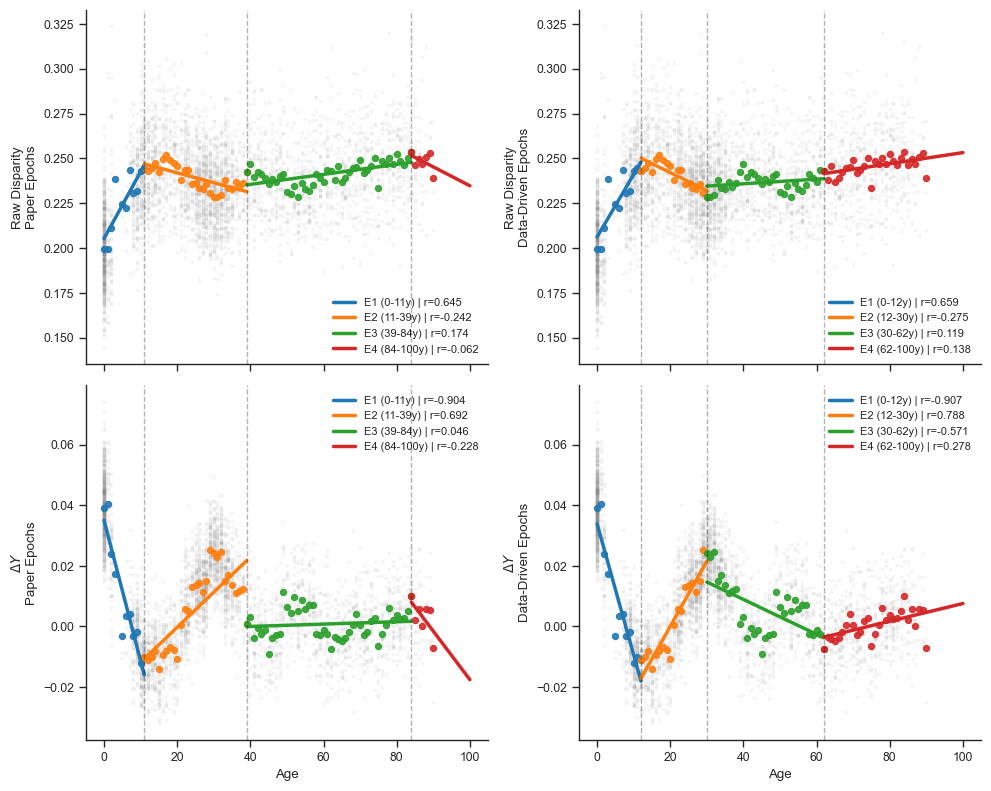

In [87]:

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
sns.set_theme(style="ticks", context="paper")

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

def plot_panel(ax, df, metric_col, epochs_dict, stats_df, strategy_name, metric_name):
    # Faint raw points
    ax.scatter(df['age'], df[metric_col], alpha=0.05, color='gray', s=5)
    
    # Calculate local grouped means for this metric
    df_grp = df.groupby('age', as_index=False)[metric_col].mean()
    
    for i, (epoch, (start, end)) in enumerate(epochs_dict.items()):
        c = colors[i % len(colors)]
        g = df_grp[(df_grp['age'] >= start) & (df_grp['age'] <= end)]
        
        ax.scatter(g['age'], g[metric_col], color=c, s=20, alpha=0.9)
        
        if len(g) > 1:
            m, b = np.polyfit(g['age'], g[metric_col], 1)
            x_fit = np.linspace(start, end, 100)
            
            # Lookup r value for legend
            r_val = stats_df.loc[(metric_name, strategy_name, epoch), 'r']
            ax.plot(x_fit, m * x_fit + b, color=c, linewidth=2.5, 
                    label=f"E{epoch} ({start}-{end}y) | r={r_val}")
            
        if start > 0:
            ax.axvline(x=start, color='black', linestyle='--', alpha=0.3, linewidth=1)

    ax.legend(frameon=False, fontsize=8, loc='best')

# Row 1: Raw Disparity
plot_panel(axes[0,0], df_all, 'disparity_res', epochs_paper, df_combined_stats, "Paper", "Raw (Y)")
axes[0,0].set_ylabel("Raw Disparity\nPaper Epochs")
plot_panel(axes[0,1], df_all, 'disparity_res', epochs_data, df_combined_stats, "Data-Driven", "Raw (Y)")
axes[0,1].set_ylabel("Raw Disparity\nData-Driven Epochs")

# Row 2: Topological Disparity (Deviation)
plot_panel(axes[1,0], df_all, 'disparity_dev_res', epochs_paper, df_combined_stats, "Paper", "Topology (ΔY)")
axes[1,0].set_ylabel(r"$\Delta Y$" + "\nPaper Epochs")
axes[1,0].set_xlabel('Age')

plot_panel(axes[1,1], df_all, 'disparity_dev_res', epochs_data, df_combined_stats, "Data-Driven", "Topology (ΔY)")
axes[1,1].set_ylabel(r"$\Delta Y$" + "\nData-Driven Epochs")
axes[1,1].set_xlabel('Age')

sns.despine()
plt.tight_layout()
plt.savefig('disparity_2x2_comparison.png', dpi=300)
plt.show()

----------------------------------------- SEX DIFFERENCES ------------------------------------------------------------

GAM revealed p=3.07e-12 sex difference in age-disparity relations for different sexes. We tthen fitted 2 models (for males and females) to obtain the trajectories for these subsets, creting the following Figure

<Figure size 600x500 with 0 Axes>

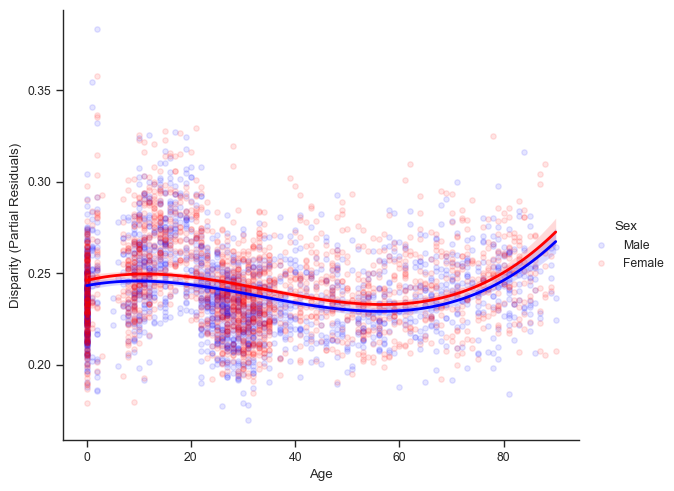

<Figure size 640x480 with 0 Axes>

In [31]:
df_sex = pd.read_csv('procdata/disparity_residuals_sex.csv')

plt.figure(figsize=(6, 5))
sns.set_theme(style="ticks", context="paper")

# Plot sex-stratified non-linear trajectories
sns.lmplot(
    data=df_sex, 
    x='age', 
    y='disparity_res', 
    hue='Sex', 
    palette={'Female': 'red', 'Male': 'blue'},
    scatter_kws={'alpha': 0.1, 's': 15}, 
    line_kws={'linewidth': 2},
    order=3, # Fits a polynomial curve to mimic the GAM spline
    height=5, 
    aspect=1.2
)

plt.xlabel('Age')
plt.ylabel('Disparity (Partial Residuals)')
sns.despine()
plt.show()
plt.savefig('results/disparity/disparity_sex_plot.png', dpi=300)

In [222]:
import pickle

data_harm.to_pickle('data_harm.pkl')
data_age_harm.to_pickle('data_age_harm.pkl')

np.savez_compressed('connectomes_harm_compressed.npz', connectomes=connectomes_harm)

-------------------------------- REGION ANALYSIS ----------------------------------------

c:\Users\Ale\Desktop\UB\NetLearn\proc_funcs.py:26: RuntimeWarning: invalid value encountered in divide
  nodal_Y = np.sum((adj / strength[:, None])**2, axis=1, where=valid[:, None])


    ROI         r         p_val   p_corrected  Significant
19  R20 -0.960312  3.011495e-14  2.710346e-12         True
69  R70 -0.912037  2.236366e-10  1.006365e-08         True
18  R19 -0.890381  2.519670e-09  6.552934e-08         True
42  R43  0.888920  2.912415e-09  6.552934e-08         True
66  R67  0.870411  1.559746e-08  2.807543e-07         True
68  R69 -0.865929  2.253632e-08  3.380448e-07         True
31  R32  0.836560  1.889535e-07  2.338063e-06         True
28  R29  0.835092  2.078278e-07  2.338063e-06         True
61  R62 -0.818103  5.873967e-07  5.873967e-06         True
43  R44  0.813703  7.555911e-07  6.800320e-06         True
37  R38  0.803047  1.354369e-06  1.108120e-05         True
67  R68  0.798970  1.677737e-06  1.258303e-05         True
34  R35 -0.777930  4.713470e-06  3.263172e-05         True
36  R37  0.774249  5.583699e-06  3.589521e-05         True
63  R64  0.760761  1.012371e-05  6.074229e-05         True


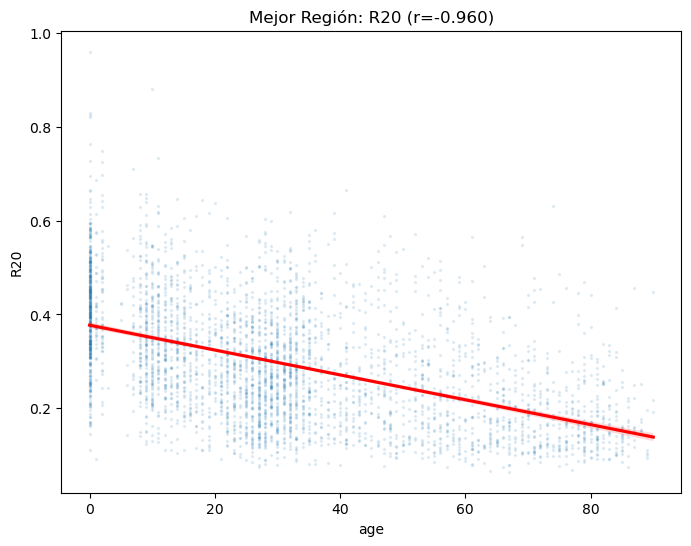

In [223]:
from proc_funcs import get_nodal_disparity_and_strength, run_roi_correlations
df_rois_disparities, df_rois_strengths = get_nodal_disparity_and_strength(connectomes_harm)

# Unimos con la edad y dataset de data_harm
df_full = pd.concat([data_harm[['age', 'dataset']], df_rois_disparities], axis=1)
#probar solo con jovenes
df_full_young = df_full[df_full['age'] <= 25]


results_young = run_roi_correlations(df_full_young, df_rois_disparities.columns, target_col='age', collapse_means=True)


winners = results_young[results_young['Significant'] == True]
print(winners.head(15))

# 7. Visualizar la mejor región
if not winners.empty:
    best_roi = winners.iloc[0]['ROI']
    r_val = winners.iloc[0]['r']
    
    plt.figure(figsize=(8, 6))
    sns.regplot(data=df_full, x='age', y=best_roi, scatter_kws={'alpha':0.1, 's':2}, line_kws={'color':'red'})
    plt.title(f"Mejor Región: {best_roi} (r={r_val:.3f})")
    plt.show()


In [224]:
#leave last column out
df_rois_disparities.columns

Index(['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9', 'R10', 'R11',
       'R12', 'R13', 'R14', 'R15', 'R16', 'R17', 'R18', 'R19', 'R20', 'R21',
       'R22', 'R23', 'R24', 'R25', 'R26', 'R27', 'R28', 'R29', 'R30', 'R31',
       'R32', 'R33', 'R34', 'R35', 'R36', 'R37', 'R38', 'R39', 'R40', 'R41',
       'R42', 'R43', 'R44', 'R45', 'R46', 'R47', 'R48', 'R49', 'R50', 'R51',
       'R52', 'R53', 'R54', 'R55', 'R56', 'R57', 'R58', 'R59', 'R60', 'R61',
       'R62', 'R63', 'R64', 'R65', 'R66', 'R67', 'R68', 'R69', 'R70', 'R71',
       'R72', 'R73', 'R74', 'R75', 'R76', 'R77', 'R78', 'R79', 'R80', 'R81',
       'R82', 'R83', 'R84', 'R85', 'R86', 'R87', 'R88', 'R89', 'R90'],
      dtype='object')

✅ Atlas encontrado: ./preprocdata/aal-SPM12/aal/atlas/AAL.nii
📍 Coordenadas extraídas: 90 regiones.


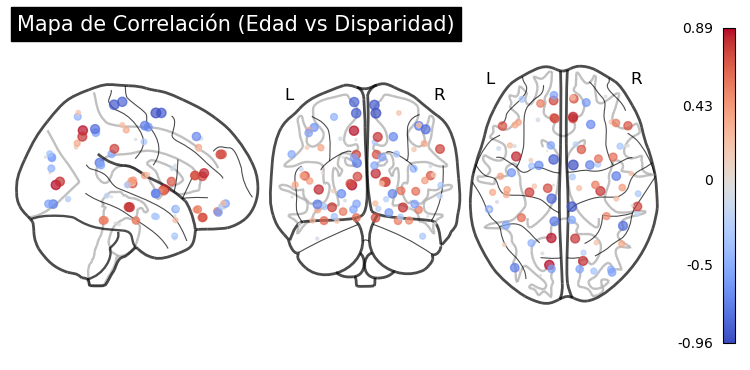

<Figure size 640x480 with 0 Axes>

In [242]:
import os
from nilearn import plotting

carpeta_destino = './preprocdata/aal-SPM12/aal/atlas/'

ruta_atlas_nii = os.path.join(carpeta_destino, 'AAL.nii')

if not os.path.exists(ruta_atlas_nii):
    # A veces está dentro de una subcarpeta, ajusta esto si es necesario
    print(f"❌ No encuentro AAL.nii en {carpeta_destino}. Revisa la carpeta.")
else:
    print(f"✅ Atlas encontrado: {ruta_atlas_nii}")

    # 4. Extraer coordenadas LOCALMENTE (Sin internet)
    # nilearn lee el archivo .nii directamente del disco duro
    coords = plotting.find_parcellation_cut_coords(ruta_atlas_nii)
    
    # 5. Recortar a las primeras 90 regiones (AAL90)
    # El archivo original tiene 116 (incluye cerebelo)
    coords_90 = coords[:90]
    
    print(f"📍 Coordenadas extraídas: {len(coords_90)} regiones.")
    
    # 6. PINTAR EL CEREBRO (Usando tu vector de correlaciones 'r')
    # Asegúrate de tener 'r_values_vector' calculado del paso anterior
    
    plotting.plot_markers(
        node_values=results_young.set_index('ROI').loc[df_rois_disparities.columns]['r'].values, 
        node_coords=coords_90, 
        node_cmap='coolwarm',
        node_size=abs(results_young.set_index('ROI').loc[df_rois_disparities.columns]['r'].values)*50,
        title="Mapa de Correlación (Edad vs Disparidad)"
    )
    plt.show()
    plt.savefig('results/disparity/brain_map_nodes.png', dpi=300)

    ROI         r         p_val   p_corrected  Significant
19  R20 -0.960312  3.011495e-14  2.710346e-12         True
69  R70 -0.912037  2.236366e-10  1.006365e-08         True
18  R19 -0.890381  2.519670e-09  6.552934e-08         True
42  R43  0.888920  2.912415e-09  6.552934e-08         True
66  R67  0.870411  1.559746e-08  2.807543e-07         True
68  R69 -0.865929  2.253632e-08  3.380448e-07         True
31  R32  0.836560  1.889535e-07  2.338063e-06         True
28  R29  0.835092  2.078278e-07  2.338063e-06         True
61  R62 -0.818103  5.873967e-07  5.873967e-06         True
43  R44  0.813703  7.555911e-07  6.800320e-06         True
37  R38  0.803047  1.354369e-06  1.108120e-05         True
67  R68  0.798970  1.677737e-06  1.258303e-05         True
34  R35 -0.777930  4.713470e-06  3.263172e-05         True
36  R37  0.774249  5.583699e-06  3.589521e-05         True
63  R64  0.760761  1.012371e-05  6.074229e-05         True


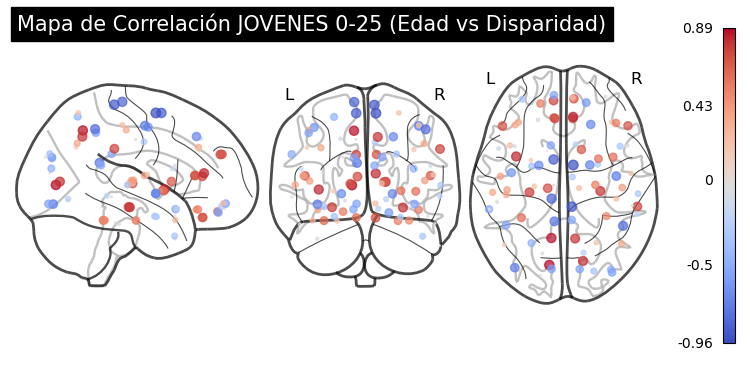

In [226]:
#probar solo con jovenes
df_full_young = df_full[df_full['age'] <= 25]
from proc_funcs import run_roi_correlations

results_young = run_roi_correlations(df_full_young, df_rois_disparities.columns, target_col='age', collapse_means=True)

winners = results_young[results_young['Significant'] == True]
print(winners.head(15))

plotting.plot_markers(
        node_values=results_young.set_index('ROI').loc[df_rois_disparities.columns]['r'].values, 
        node_coords=coords_90, 
        node_cmap='coolwarm',
        node_size=abs(results_young.set_index('ROI').loc[df_rois_disparities.columns]['r'].values)*50,
        title="Mapa de Correlación JOVENES 0-25 (Edad vs Disparidad)"
    )
plt.show()


📊 Analizando contribución de 90 regiones...

--- VERDAD MATEMÁTICA ---
Promedio de pendientes individuales: 0.000192
Regiones que tiran hacia ARRIBA: 51
Regiones que tiran hacia ABAJO:  39
Fuerza media hacia ARRIBA:       0.000836
Fuerza media hacia ABAJO:        -0.000651


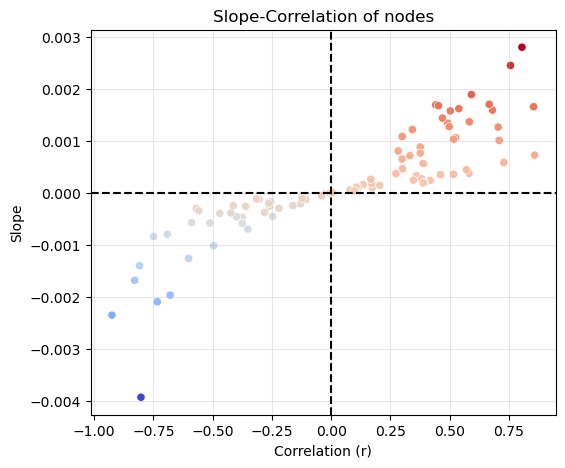

<Figure size 640x480 with 0 Axes>

In [227]:
# Función para calcular pendiente (m) y correlación (r)
def get_slope_and_corr(x, y):
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    return slope, r_value



# 1. Preparar datos
results_contribution = []
roi_cols = df_rois_disparities.columns.tolist()  # Use all ROI columns from df_rois

print(f"📊 Analizando contribución de {len(roi_cols)} regiones...")

# 2. Calcular Slope y R para cada región
for roi in roi_cols:
    # Usamos los datos promediados por edad como has hecho antes
    clean_data = df_full[['age', roi]].dropna().groupby('age').mean().reset_index()
    
    if len(clean_data) > 10:
        slope, r = get_slope_and_corr(clean_data['age'], clean_data[roi])
        results_contribution.append({
            'ROI': roi,
            'Slope': slope,   # Cuánto cambia Y por cada año (Magnitud)
            'Corr': r         # Qué tan consistente es (Forma)
        })

df_contrib = pd.DataFrame(results_contribution)

# 3. VERIFICACIÓN MATEMÁTICA
avg_slope = df_contrib['Slope'].mean()
print(f"\n--- VERDAD MATEMÁTICA ---")
print(f"Promedio de pendientes individuales: {avg_slope:.6f}")

# 4. ¿Quién gana? (Positivos vs Negativos)
positive_drivers = df_contrib[df_contrib['Slope'] > 0]
negative_drivers = df_contrib[df_contrib['Slope'] < 0]

print(f"Regiones que tiran hacia ARRIBA: {len(positive_drivers)}")
print(f"Regiones que tiran hacia ABAJO:  {len(negative_drivers)}")
print(f"Fuerza media hacia ARRIBA:       {positive_drivers['Slope'].mean():.6f}")
print(f"Fuerza media hacia ABAJO:        {negative_drivers['Slope'].mean():.6f}")

#export all these results to a csv
df_contrib.to_csv('results/disparity/roi_contributions.csv', index=True)


# 5. Visualización
plt.figure(figsize=(6,5))
sns.scatterplot(data=df_contrib, x='Corr', y='Slope', hue='Slope', palette='coolwarm', legend=False)
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')
plt.title("Slope-Correlation of nodes")
plt.xlabel("Correlation (r)")
plt.ylabel("Slope")
plt.grid(True, alpha=0.3)
plt.show()
plt.savefig('results/disparity/slope_corr_scatter.png', dpi=300)



In [228]:
disparities_harm = calculate_disparity(connectomes_harm)

data_harm = pd.DataFrame({
    'Subject': np.arange(connectomes_harm.shape[0]),
    'Disparity_Y': disparities_harm
})

data_harm = pd.concat([data_harm, demo_harm], axis=1)


✅ Cálculo terminado. Media Global Y: 0.2415


In [229]:
#select connectomes with highest and lowest disparity and export them as .dat files

extreme_disparities = np.argsort(disparities)
print("Sujeto con menor disparidad (Y):", extreme_disparities[0]) 
print("Sujeto con mayor disparidad (Y):", extreme_disparities[-1])
#Exportar los connectomas extremos a .dat
low_disp_connectome = connectomes_harm[extreme_disparities[0]] 
high_disp_connectome = connectomes_harm[extreme_disparities[-1]] 
np.savetxt('ESNcpp/connectome_low_disparity.dat', low_disp_connectome, fmt='%.4f') 
np.savetxt('ESNcpp/connectome_high_disparity.dat', high_disp_connectome, fmt='%.4f')

Sujeto con menor disparidad (Y): 514
Sujeto con mayor disparidad (Y): 1081


In [232]:
from Graph import Graph
import networkx as nx

low_disp_connectome.dtype
low_disp_connectome.shape



# 2. Función auxiliar para convertir Matrix -> Tu Clase Graph
def matrix_to_nx(matrix, roi_labels=df_rois_disparities.columns):
    # A) Convertir numpy a NetworkX (preserva pesos en 'weight')
    nx_g = nx.from_numpy_array(matrix)
    mapping = {i: name for i, name in enumerate(roi_labels)}
    nx_g = nx.relabel_nodes(nx_g, mapping)
    
    # C) Instanciar TU clase
    return Graph(nx_g)


graph_low = matrix_to_nx(low_disp_connectome)
graph_high = matrix_to_nx(high_disp_connectome)

graph_low.describe_graph()
graph_high.describe_graph()


nx.write_gexf(graph_low.G, "ESN_Gephi/graph_low_disparity.gexf")
nx.write_gexf(graph_high.G, "ESN_Gephi/graph_high_disparity.gexf")


Graph: 90 nodes, 603 edges


Graph: 90 nodes, 465 edges



In [233]:
nx.adjacency_matrix(graph_low.G)


<Compressed Sparse Row sparse array of dtype 'float64'
	with 1206 stored elements and shape (90, 90)>

In [234]:
# Comprobación rápida: ¿Sube Y pero baja la Fuerza?
data_harm['Strength'] = [np.sum(c) for c in connectomes_harm]
print("Correlación Edad vs Strength:", stats.pearsonr(data_harm['age'], data_harm['Strength']))



Correlación Edad vs Strength: PearsonRResult(statistic=0.4246020297922468, pvalue=2.761213709154618e-166)
